**1. TITANIC DATASET**

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
file_path="/content/titanic.csv"

In [ ]:
df=pd.read_csv("/content/titanic.csv")

In [ ]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.shape

(891, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.duplicated().value_counts()

,count
False,891


In [ ]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [ ]:
missing=df.isnull().sum()



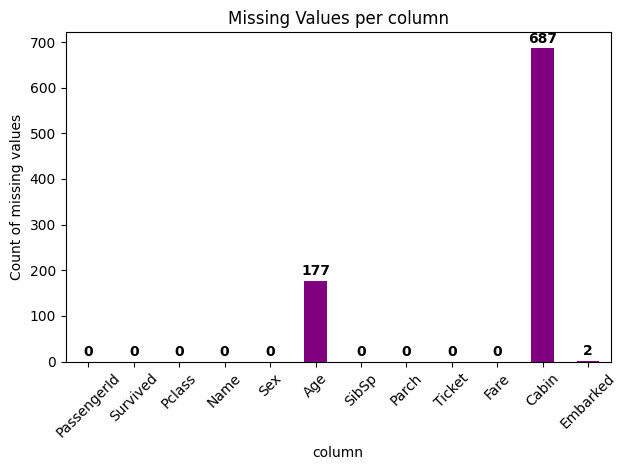

In [ ]:
ax=missing.plot(kind='bar',color='purple')
plt.title("Missing Values per column")
plt.xlabel("column")
plt.ylabel("Count of missing values")
plt.xticks(rotation=45)
for index, value in enumerate(missing):
  plt.text(index,value+5,str(value),ha='center',va='bottom',fontsize=10,fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
df=df.drop(columns=['Cabin'])

In [ ]:
df['Age']= df['Age'].fillna(df['Age'].median())

In [ ]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
survival_counts = df['Survived'].value_counts()
print("Survival Counts:\n", survival_counts)

Survival Counts:
 Survived
0    549
1    342
Name: count, dtype: int64


/tmp/ipykernel_7204/927445151.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=df, palette='pastel')


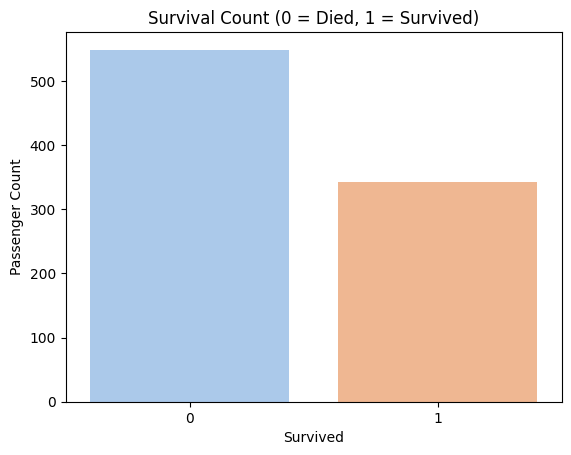

In [ ]:
sns.countplot(x='Survived', data=df, palette='pastel')
plt.title('Survival Count (0 = Died, 1 = Survived)')
plt.xlabel('Survived')
plt.ylabel('Passenger Count')
plt.show()

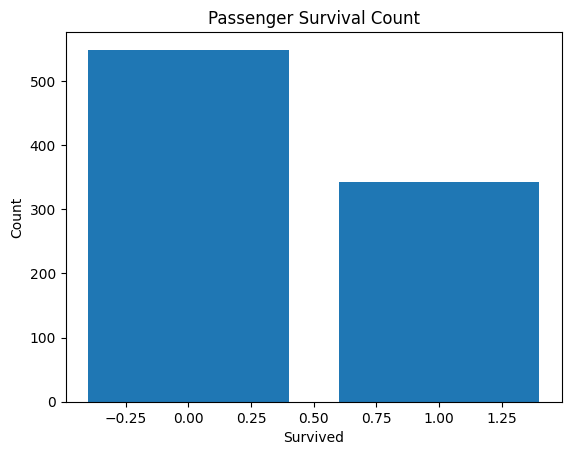

In [ ]:
counts = df['Survived'].value_counts() # counts of 0 and 1
plt.bar(counts.index, counts.values)
plt.xlabel("Survived")
plt.ylabel("Count")
plt.title("Passenger Survival Count")
plt.show()

In [ ]:
gender_counts = df['Sex'].value_counts()
print("\nGender Counts:\n", gender_counts)


Gender Counts:
 Sex
male      577
female    314
Name: count, dtype: int64


In [ ]:
survival_by_gender = df.groupby(['Sex', 'Survived']).size()
print("\nSurvival by Gender:\n", survival_by_gender)


Survival by Gender:
 Sex     Survived
female  0            81
        1           233
male    0           468
        1           109
dtype: int64


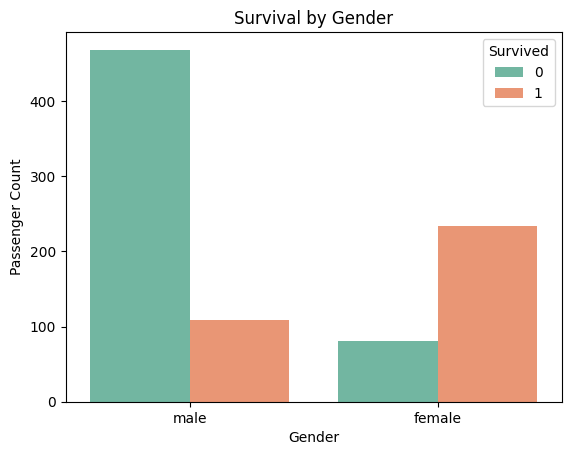

In [ ]:
sns.countplot(x='Sex', hue='Survived', data=df, palette='Set2')
plt.title('Survival by Gender')
plt.xlabel('Gender')
plt.ylabel('Passenger Count')
plt.legend(title='Survived')
plt.show()

In [ ]:
pclass_counts = df['Pclass'].value_counts()
print("\nPassenger Class Counts:\n", pclass_counts)


Passenger Class Counts:
 Pclass
3    491
1    216
2    184
Name: count, dtype: int64


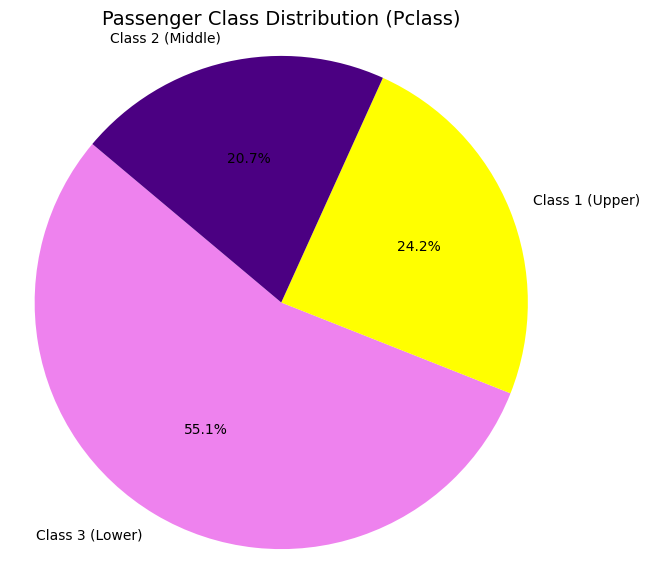

In [ ]:
labels = ['Class 3 (Lower)', 'Class 1 (Upper)', 'Class 2 (Middle)']
plt.figure(figsize=(7, 7))
plt.pie(pclass_counts, labels=labels, autopct='%1.1f%%', startangle=140, colors=['violet', 'yellow', 'indigo'])
plt.title('Passenger Class Distribution (Pclass)', fontsize=14)
plt.axis('equal')
plt.show()

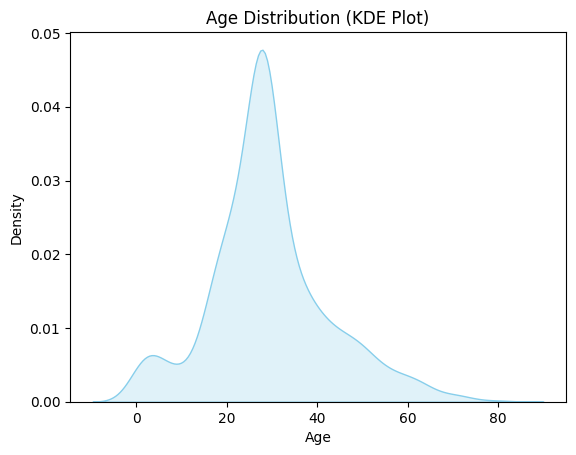

In [ ]:
sns.kdeplot(df['Age'], fill=True, color='skyblue')
plt.title('Age Distribution (KDE Plot)')
plt.xlabel('Age')
plt.ylabel('Density')
plt.show()

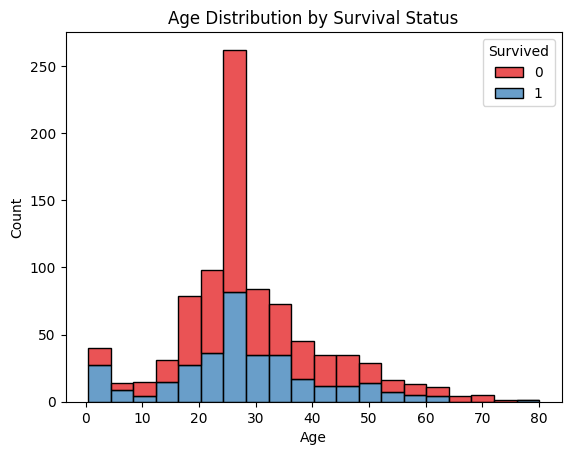

In [ ]:
sns.histplot(data=df, x='Age', hue='Survived', multiple='stack', bins=20, palette='Set1')
plt.title('Age Distribution by Survival Status')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

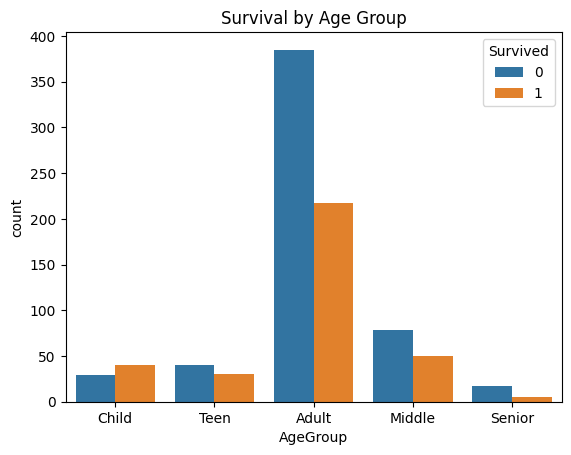

In [ ]:
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 12, 18, 40, 60, 100], labels=['Child', 'Teen', 'Adult', 'Middle', 'Senior'])
sns.countplot(x='AgeGroup', hue='Survived', data=df)
plt.title('Survival by Age Group')
plt.show()

**2. IMDB DATASET**

In [ ]:
file_path="/content/imdb_data.csv"

In [ ]:
df=pd.read_csv(file_path)

In [ ]:
df

,id,belongs_to_collection,budget,genres,homepage,imdb_id,original_language,original_title,overview,popularity,...,release_date,runtime,spoken_languages,status,tagline,title,Keywords,cast,crew,revenue
0,1,"[{'id': 313576, 'name': 'Hot Tub Time Machine ...",14000000,"[{'id': 35, 'name': 'Comedy'}]",NaN,tt2637294,en,Hot Tub Time Machine 2,"When Lou, who has become the ""father of the In...",6.575393,...,2/20/15,93.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The Laws of Space and Time are About to be Vio...,Hot Tub Time Machine 2,"[{'id': 4379, 'name': 'time travel'}, {'id': 9...","[{'cast_id': 4, 'character': 'Lou', 'credit_id...","[{'credit_id': '59ac067c92514107af02c8c8', 'de...",12314651
1,2,"[{'id': 107674, 'name': 'The Princess Diaries ...",40000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,tt0368933,en,The Princess Diaries 2: Royal Engagement,Mia Thermopolis is now a college graduate and ...,8.248895,...,8/6/04,113.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,It can take a lifetime to find true love; she'...,The Princess Diaries 2: Royal Engagement,"[{'id': 2505, 'name': 'coronation'}, {'id': 42...","[{'cast_id': 1, 'character': 'Mia Thermopolis'...","[{'credit_id': '52fe43fe9251416c7502563d', 'de...",95149435
2,3,NaN,3300000,"[{'id': 18, 'name': 'Drama'}]",http://sonyclassics.com/whiplash/,tt2582802,en,Whiplash,"Under the direction of a ruthless instructor, ...",64.299990,...,10/10/14,105.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The road to greatness can take you to the edge.,Whiplash,"[{'id': 1416, 'name': 'jazz'}, {'id': 1523, 'n...","[{'cast_id': 5, 'character': 'Andrew Neimann',...","[{'credit_id': '54d5356ec3a3683ba0000039', 'de...",13092000
3,4,NaN,1200000,"[{'id': 53, 'name': 'Thriller'}, {'id': 18, 'n...",http://kahaanithefilm.com/,tt1821480,hi,Kahaani,Vidya Bagchi (Vidya Balan) arrives in Kolkata ...,3.174936,...,3/9/12,122.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,NaN,Kahaani,"[{'id': 10092, 'name': 'mystery'}, {'id': 1054...","[{'cast_id': 1, 'character': 'Vidya Bagchi', '...","[{'credit_id': '52fe48779251416c9108d6eb', 'de...",16000000
4,5,NaN,0,"[{'id': 28, 'name': 'Action'}, {'id': 53, 'nam...",NaN,tt1380152,ko,마린보이,Marine Boy is the story of a former national s...,1.148070,...,2/5/09,118.0,"[{'iso_639_1': 'ko', 'name': '한국어/조선말'}]",Released,NaN,Marine Boy,NaN,"[{'cast_id': 3, 'character': 'Chun-soo', 'cred...","[{'credit_id': '52fe464b9251416c75073b43', 'de...",3923970
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,2996,NaN,0,"[{'id': 35, 'name': 'Comedy'}, {'id': 10749, '...",NaN,tt0109403,en,Chasers,Military men Rock Reilly and Eddie Devane are ...,9.853270,...,4/22/94,102.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,It was supposed to be a routine prisoner trans...,Chasers,"[{'id': 378, 'name': 'prison'}, {'id': 572, 'n...","[{'cast_id': 2, 'character': 'Rock Reilly', 'c...","[{'credit_id': '52fe4494c3a368484e02ac7d', 'de...",1596687
2996,2997,NaN,0,"[{'id': 18, 'name': 'Drama'}, {'id': 10402, 'n...",NaN,tt2364975,sv,Vi är bäst!,Three girls in 1980s Stockholm decide to form ...,3.727996,...,3/28/13,102.0,"[{'iso_639_1': 'sv', 'name': 'svenska'}]",Released,NaN,We Are the Best!,"[{'id': 1192, 'name': 'sweden'}, {'id': 4470, ...","[{'cast_id': 5, 'character': 'Bobo', 'credit_i...","[{'credit_id': '5716b72ac3a3686678012c84', 'de...",180590
2997,2998,NaN,65000000,"[{'id': 80, 'name': 'Crime'}, {'id': 28, 'name...",NaN,tt0116908,en,The Long Kiss Goodnight,"Samantha Caine, suburban homemaker, is the ide...",14.482345,...,10/11/96,120.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,What's forgotten is not always gone.,The Long Kiss Goodnight,"[{'id': 441, 'name': 'assassination'}, {'id': ...","[{'cast_id': 10, 'character': 'Samantha Caine ...","[{'credit_id': '52fe443a9251416c7502d579', 'de...",89456761
2998,2999,NaN,42000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 10749, '...",http://www

In [ ]:
df.head()

,id,belongs_to_collection,budget,genres,homepage,imdb_id,original_language,original_title,overview,popularity,...,release_date,runtime,spoken_languages,status,tagline,title,Keywords,cast,crew,revenue
0,1,"[{'id': 313576, 'name': 'Hot Tub Time Machine ...",14000000,"[{'id': 35, 'name': 'Comedy'}]",NaN,tt2637294,en,Hot Tub Time Machine 2,"When Lou, who has become the ""father of the In...",6.575393,...,2/20/15,93.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The Laws of Space and Time are About to be Vio...,Hot Tub Time Machine 2,"[{'id': 4379, 'name': 'time travel'}, {'id': 9...","[{'cast_id': 4, 'character': 'Lou', 'credit_id...","[{'credit_id': '59ac067c92514107af02c8c8', 'de...",12314651
1,2,"[{'id': 107674, 'name': 'The Princess Diaries ...",40000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,tt0368933,en,The Princess Diaries 2: Royal Engagement,Mia Thermopolis is now a college graduate and ...,8.248895,...,8/6/04,113.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,It can take a lifetime to find true love; she'...,The Princess Diaries 2: Royal Engagement,"[{'id': 2505, 'name': 'coronation'}, {'id': 42...","[{'cast_id': 1, 'character': 'Mia Thermopolis'...","[{'credit_id': '52fe43fe9251416c7502563d', 'de...",95149435
2,3,NaN,3300000,"[{'id': 18, 'name': 'Drama'}]",http://sonyclassics.com/whiplash/,tt2582802,en,Whiplash,"Under the direction of a ruthless instructor, ...",64.299990,...,10/10/14,105.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The road to greatness can take you to the edge.,Whiplash,"[{'id': 1416, 'name': 'jazz'}, {'id': 1523, 'n...","[{'cast_id': 5, 'character': 'Andrew Neimann',...","[{'credit_id': '54d5356ec3a3683ba0000039', 'de...",13092000
3,4,NaN,1200000,"[{'id': 53, 'name': 'Thriller'}, {'id': 18, 'n...",http://kahaanithefilm.com/,tt1821480,hi,Kahaani,Vidya Bagchi (Vidya Balan) arrives in Kolkata ...,3.174936,...,3/9/12,122.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,NaN,Kahaani,"[{'id': 10092, 'name': 'mystery'}, {'id': 1054...","[{'cast_id': 1, 'character': 'Vidya Bagchi', '...","[{'credit_id': '52fe48779251416c9108d6eb', 'de...",16000000
4,5,NaN,0,"[{'id': 28, 'name': 'Action'}, {'id': 53, 'nam...",NaN,tt1380152,ko,마린보이,Marine Boy is the story of a former national s...,1.148070,...,2/5/09,118.0,"[{'iso_639_1': 'ko', 'name': '한국어/조선말'}]",Released,NaN,Marine Boy,NaN,"[{'cast_id': 3, 'character': 'Chun-soo', 'cred...","[{'credit_id': '52fe464b9251416c75073b43', 'de...",3923970


In [ ]:
df.shape

(3000, 23)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     3000 non-null   int64  
 1   belongs_to_collection  604 non-null    object 
 2   budget                 3000 non-null   int64  
 3   genres                 2993 non-null   object 
 4   homepage               946 non-null    object 
 5   imdb_id                3000 non-null   object 
 6   original_language      3000 non-null   object 
 7   original_title         3000 non-null   object 
 8   overview               2992 non-null   object 
 9   popularity             3000 non-null   float64
 10  poster_path            2999 non-null   object 
 11  production_companies   2844 non-null   object 
 12  production_countries   2945 non-null   object 
 13  release_date           3000 non-null   object 
 14  runtime                2998 non-null   float64
 15  spok

In [ ]:
df.duplicated().value_counts()

,count
False,3000


In [ ]:
print(df.isnull().sum())

id                          0
belongs_to_collection    2396
budget                      0
genres                      7
homepage                 2054
imdb_id                     0
original_language           0
original_title              0
overview                    8
popularity                  0
poster_path                 1
production_companies      156
production_countries       55
release_date                0
runtime                     2
spoken_languages           20
status                      0
tagline                   597
title                       0
Keywords                  276
cast                       13
crew                       16
revenue                     0
dtype: int64


In [ ]:
missing = df.isnull().sum()

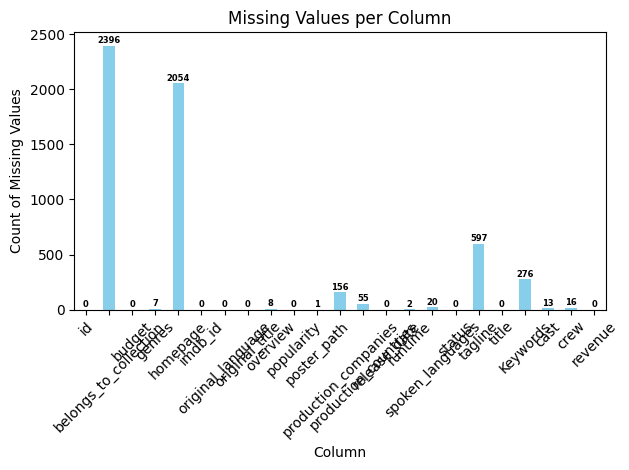

In [ ]:
ax = missing.plot(kind='bar', color='skyblue')
plt.title('Missing Values per Column')
plt.ylabel('Count of Missing Values')
plt.xlabel('Column')
plt.xticks(rotation=45)
for index, value in enumerate(missing):
    plt.text(index, value+5, str(value), ha='center', va='bottom', fontsize=6, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
df = df.drop(columns=['belongs_to_collection'])

In [ ]:
df['homepage'] = df['homepage'].fillna('')

In [ ]:
print(df.isnull().sum())

id                        0
budget                    0
genres                    7
homepage                  0
imdb_id                   0
original_language         0
original_title            0
overview                  8
popularity                0
poster_path               1
production_companies    156
production_countries     55
release_date              0
runtime                   2
spoken_languages         20
status                    0
tagline                 597
title                     0
Keywords                276
cast                     13
crew                     16
revenue                   0
dtype: int64


In [ ]:
df['runtime'] = df['runtime'].fillna(df['runtime'].median())

for col in ['genres', 'overview', 'poster_path', 'production_companies', 'production_countries', 'spoken_languages', 'Keywords', 'cast', 'crew']:
    df[col] = df[col].fillna('')

In [ ]:
print(df.isnull().sum())

id                        0
budget                    0
genres                    0
homepage                  0
imdb_id                   0
original_language         0
original_title            0
overview                  0
popularity                0
poster_path               0
production_companies      0
production_countries      0
release_date              0
runtime                   0
spoken_languages          0
status                    0
tagline                 597
title                     0
Keywords                  0
cast                      0
crew                      0
revenue                   0
dtype: int64


In [ ]:
df['tagline'] = df['tagline'].fillna('')

In [ ]:
print(df.isnull().sum())

id                      0
budget                  0
genres                  0
homepage                0
imdb_id                 0
original_language       0
original_title          0
overview                0
popularity              0
poster_path             0
production_companies    0
production_countries    0
release_date            0
runtime                 0
spoken_languages        0
status                  0
tagline                 0
title                   0
Keywords                0
cast                    0
crew                    0
revenue                 0
dtype: int64


In [ ]:
print("Summary Statistics:")
print(df.describe(include='all'))

Summary Statistics:
                 id        budget                         genres homepage  \
count   3000.000000  3.000000e+03                           3000     3000   
unique          NaN           NaN                            873      942   
top             NaN           NaN  [{'id': 18, 'name': 'Drama'}]            
freq            NaN           NaN                            266     2054   
mean    1500.500000  2.253133e+07                            NaN      NaN   
std      866.169729  3.702609e+07                            NaN      NaN   
min        1.000000  0.000000e+00                            NaN      NaN   
25%      750.750000  0.000000e+00                            NaN      NaN   
50%     1500.500000  8.000000e+06                            NaN      NaN   
75%     2250.250000  2.900000e+07                            NaN      NaN   
max     3000.000000  3.800000e+08                            NaN      NaN   

          imdb_id original_language original_title over

In [ ]:
top_languages = df['original_language'].value_counts().head(3)
print("\nTop 3 Languages:")
print(top_languages)



Top 3 Languages:
original_language
en    2575
fr      78
ru      47
Name: count, dtype: int64


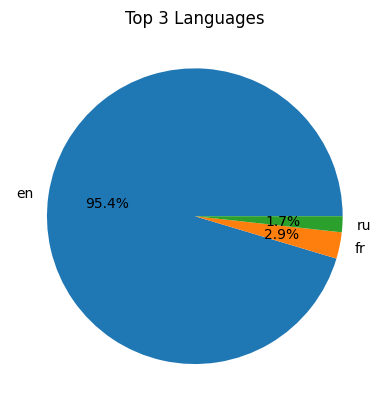

In [ ]:
plt.figure()
top_languages.plot(kind='pie', autopct='%1.1f%%')
plt.title("Top 3 Languages")
plt.ylabel("")
plt.show()

In [ ]:
print("\nTop 3 dominant languages:")
print(top_languages.index.tolist())


Top 3 dominant languages:
['en', 'fr', 'ru']


In [ ]:
df['genres'] = df['genres'].astype(str)
genres_series = df['genres'].str.split(',')

In [ ]:
from collections import Counter
genre_list = [genre.strip() for sublist in genres_series for genre in sublist]
genre_counts = Counter(genre_list)
genre_df = pd.DataFrame(genre_counts.items(), columns=['Genre', 'Count'])
genre_df = genre_df.sort_values(by='Count', ascending=False)

print("\nGenre counts:")
print(genre_df)


Genre counts:
                  Genre  Count
4      'name': 'Drama'}    960
9            [{'id': 18    785
3             {'id': 18    746
2     'name': 'Comedy'}    685
15            {'id': 53    673
..                  ...    ...
72   'name': 'Foreign'}      7
75                           7
76        [{'id': 10769      2
77        [{'id': 10770      1
78  'name': 'TV Movie'}      1

[79 rows x 2 columns]


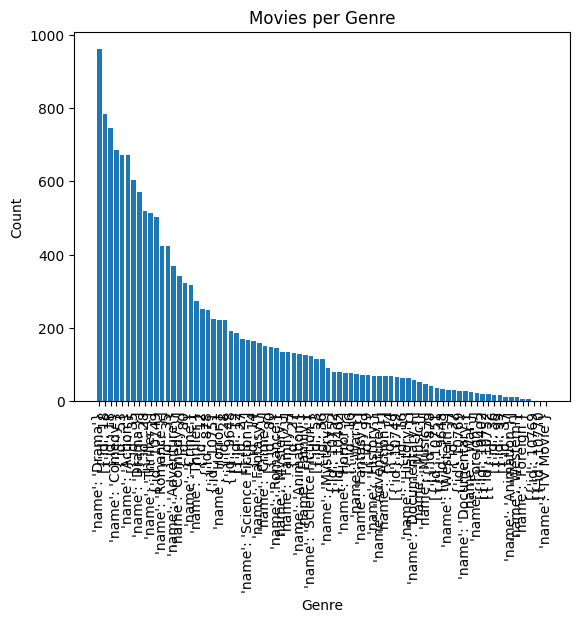

In [ ]:
plt.figure()
plt.bar(genre_df['Genre'], genre_df['Count'])
plt.xticks(rotation=90)
plt.title("Movies per Genre")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.show()

In [ ]:
df_sorted = df.sort_values(by='popularity', ascending=False)

In [ ]:
top10 = df_sorted[['title', 'popularity']].head(10)
print("\nTop 10 Most Popular Films:")
print(top10)


Top 10 Most Popular Films:
                               title  popularity
518                     Wonder Woman  294.337037
684             Beauty and the Beast  287.253654
1695                     Baby Driver  228.032744
2326                        Deadpool  187.860492
2126  Guardians of the Galaxy Vol. 2  185.330992
1309                       Gone Girl  154.801009
1715  War for the Planet of the Apes  146.161786
1673                 The Dark Knight  123.167259
1126                    The Avengers   89.887648
2293                      The Circle   88.439243


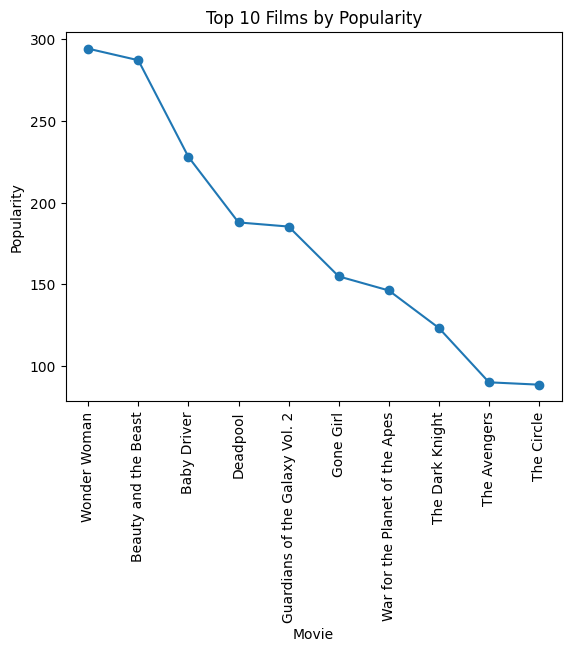

In [ ]:
plt.figure()
plt.plot(top10['title'], top10['popularity'], marker='o')
plt.xticks(rotation=90)
plt.title("Top 10 Films by Popularity")
plt.xlabel("Movie")
plt.ylabel("Popularity")
plt.show()

In [ ]:
top_budget = df.sort_values(by='budget', ascending=False).head(7)

In [ ]:
print("\nTop 7 Highest Budget Films:")
print(top_budget[['title', 'budget']])


Top 7 Highest Budget Films:
                                            title     budget
2135  Pirates of the Caribbean: On Stranger Tides  380000000
2209     Pirates of the Caribbean: At World's End  300000000
2770                      Avengers: Age of Ultron  280000000
1425                             Superman Returns  270000000
1630                Transformers: The Last Knight  260000000
1270                                  John Carter  260000000
666           The Hobbit: The Desolation of Smaug  250000000


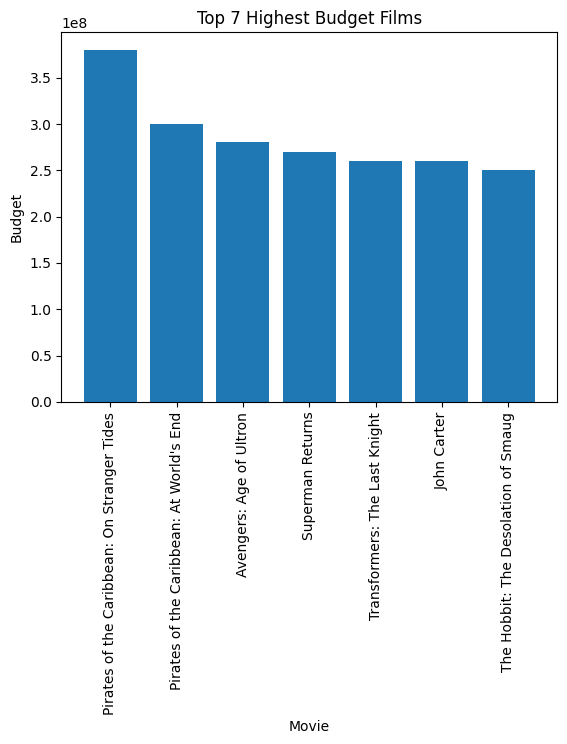

In [ ]:
plt.figure()
plt.bar(top_budget['title'], top_budget['budget'])
plt.xticks(rotation=90)
plt.title("Top 7 Highest Budget Films")
plt.xlabel("Movie")
plt.ylabel("Budget")
plt.show()